
* **Impossible Values & Placeholders:**
  An evaluation of the descriptive statistics—specifically a minimum of $13.70\text{ dB-Hz}$ and a maximum of $47.80\text{ dB-Hz}$—reveals **no impossible values or artificial placeholders** (such as `-999`, `9999`, or default error codes). The recorded metrics reside entirely within valid physical boundaries for smartphone GNSS telemetry, where carrier-to-noise ratios rarely exceed $50\text{--}55\text{ dB-Hz}$ under standard conditions.

* **Unreasonable Zeros:**
  There are **no unreasonable zero values** present in the dataset (with the minimum valid observation starting at $13.70\text{ dB-Hz}$). From a hardware perspective, if a satellite's carrier-to-noise density drops to zero or falls beneath the receiver's tracking lock threshold (typically below $10\text{--}15\text{ dB-Hz}$), the smartphone channel loses lock and completely omits or drops the record for that epoch rather than logging a literal `0.0` entry.

* **What do these values tell us about the data?**
  * **Central Tendency & Symmetry:** The mean ($33.71\text{ dB-Hz}$) and median ($34.20\text{ dB-Hz}$) are closely aligned, accompanied by a minor negative skewness ($-0.41$). This indicates a relatively balanced central distribution with a slight physical tail leaning toward lower signal strengths.
  * **Environmental Impact (Urban Canyons):** A median signal strength of roughly $34\text{ dB-Hz}$ reflects typical smartphone operation in urban or obstructed environments, where structural reflections and multipath interference degrade signal power compared to pristine open-sky setups.
  * **Outlier Sensitivity Comparison:** The outlier detection methods yield starkly different results—Z-score flags $59$ outliers, IQR flags $131$, while the robust Modified MAD method identifies only $4$ extreme outliers. This discrepancy demonstrates that standard parametric and quartile-based rules overreact to the natural lower tail caused by urban signal attenuation, whereas the MAD method provides a far more robust isolation of true statistical anomalies against heavy-tailed physical sensor noise.

* **Zero Variance Columns**
* `MessageType`:
  The `MessageType` column exhibits zero variance, constantly evaluating to "Raw". This is expected as a structural metadata prefix and requires no modification.

* `LeapSecond` & `TimeOffsetNanos`:
  Fields like `LeapSecond` and `TimeOffsetNanos` remain constant or change only across extended timescales (such as years or major UTC corrections), making their static nature entirely normal during a standard mobile logging session.

* `HardwareClockDiscontinuityCount`:
  This metric depends entirely on underlying receiver hardware stability. A constant value indicates that no hardware clock resets or discontinuities occurred during the data acquisition window.

* `MultipathIndicator` (Critical Sensor Evaluation):
  Unlike the structural constants above, a static or unvarying `MultipathIndicator` warrants critical engineering attention. Given that GNSS telemetry captured in dense urban canyons is heavily subjected to signal reflections and multipath interference, a flat or unpopulated indicator suggests that the smartphone chipset failed to dynamically track or flag these signal perturbations, highlighting a potential limitation or reporting failure in the internal sensor logic.

* **High Variance Columns**
* Nature of the Variables:
  Columns exhibiting exceptionally high variance or near-total unique values (high cardinality) primarily represent continuous physical measurements (such as spatial coordinates and pseudoranges) and high-resolution time epochs.

* High-Precision Data Types:
  These metrics are actively recorded using 64-bit floating-point architectures or nanosecond-level integer resolution. At this extreme level of mathematical granularity, even microscopic fluctuations in the sensor readings result in distinctly unique numerical outputs.

* Physical Dynamics & Orbital Kinematics:
  GNSS telemetry is fundamentally dynamic. Because the satellites are in continuous, high-speed orbital motion—and the smartphone receiver itself is often moving through a dynamic environment—the spatial geometry between the receiver and the satellite constellation shifts every millisecond. Consequently, the statistical probability of capturing the exact same physical distance, location coordinate, or time offset twice is infinitesimally low, naturally driving the variance and unique value counts to their maximum.



---
## 1. Environment Setup & Configuration
We configure our analytical environment by importing essential data science libraries. Global visualization properties are styled to ensure clean, publication-ready figures.
    


In [1]:
import os
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

# Configure visualization settings globally
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
warnings.filterwarnings("ignore")

print("Environment setup completed successfully.")


Environment setup completed successfully.



---
## 2. Dataset Selection & Background Description
### 2.1 Overview & Source
* **Dataset File:** `device_gnss_train_p4xl.csv` (Google Smartphone Decimeter Challenge dataset).
* **Source & Collecting Body:** Collected via professional Android logging frameworks in smartphones during dynamic real-world driving/walking campaigns managed by Google and academic partners for positioning research.
* **Purpose of Collection:** To capture raw Global Navigation Satellite System (GNSS) telemetry (pseudoranges, carrier-to-noise ratios, Doppler shifts, and satellite geometry) to benchmark and improve smartphone sub-meter geolocation accuracy in urban canyons.

### 2.2 Domain Knowledge Integration & Biases
* **Domain Context:** Smartphones use low-cost, linearly polarized patch antennas prone to multipath interference (signals bouncing off buildings). Unlike geodetic receivers, smartphone raw measurements exhibit high clock drift and noise floor fluctuations.
* **Operational vs. Research Collection:** This dataset was compiled for **research and benchmarking**, meaning it includes severe multi-path distortions typical of real-world urban operations rather than controlled laboratory environments.
* **Inherent Biases:** Urban recording bias (devices heavily sampled in downtown metropolitan areas with tall structures, skewing elevation angles and signal tracking reliability).
    



---
## 3. Meta-Analysis & Datastructure Inspection
We load the dataset and perform structural meta-analysis to verify dimensions, column naming conventions, and data types.
    


In [2]:
dataset_path = "device_gnss_train_p4xl.csv"

if not os.path.exists(dataset_path):
    raise FileNotFoundError(f"Target file not found: {dataset_path}")

file_size_mb = os.path.getsize(dataset_path) / (1024 * 1024)
df = pd.read_csv(dataset_path)

print("=" * 70)
print("SECTION 3: META-ANALYSIS & DATASTRUCTURE INSPECTION")
print("=" * 70)
print(f"File Name: {os.path.basename(dataset_path)}")
print(f"File Size: {file_size_mb:.2f} MB")
print(f"Dimensions: {df.shape[0]:,} rows x {df.shape[1]} columns")
print("-" * 70)

display(df.head(3))


SECTION 3: META-ANALYSIS & DATASTRUCTURE INSPECTION
File Name: device_gnss_train_p4xl.csv
File Size: 30.55 MB
Dimensions: 48,481 rows x 58 columns
----------------------------------------------------------------------


,MessageType,utcTimeMillis,TimeNanos,LeapSecond,TimeUncertaintyNanos,FullBiasNanos,BiasNanos,BiasUncertaintyNanos,DriftNanosPerSecond,DriftUncertaintyNanosPerSecond,...,SvVelocityYEcefMetersPerSecond,SvVelocityZEcefMetersPerSecond,SvClockBiasMeters,SvClockDriftMetersPerSecond,IsrbMeters,IonosphericDelayMeters,TroposphericDelayMeters,WlsPositionXEcefMeters,WlsPositionYEcefMeters,WlsPositionZEcefMeters
0,Raw,1593045251447,22822513000000,18,NaN,-1277057646934970240,0.366306,21.479316,11.443134,11.805236,...,45.224788,2921.185153,-114240.988444,-0.002747,0.0,2.990955,3.331083,-2.692779e+06,-4.297235e+06,3.855231e+06
1,Raw,1593045251447,22822513000000,18,NaN,-1277057646934970240,0.366306,21.479316,11.443134,11.805236,...,2683.345352,728.348308,6344.270928,0.000551,0.0,4.233148,9.595780,-2.692779e+06,-4.297235e+06,3.855231e+06
2,Raw,1593045251447,22822513000000,18,NaN,-1277057646934970240,0.366306,21.479316,11.443134,11.805236,...,2112.145384,1639.422495,-66543.908262,-0.000458,0.0,3.189828,4.111674,-2.692779e+06,-4.297235e+06,3.855231e+06



### 3.1 Data Types & Column Logic Inspection
We examine column types and null counts across the schema.
    


In [3]:
meta_summary = pd.DataFrame({
    "Data_Type": df.dtypes,
    "Non_Null_Count": df.notnull().sum(),
    "Null_Count": df.isnull().sum(),
    "Null_Percentage": (df.isnull().sum() / len(df)) * 100,
    "Unique_Values": df.nunique()
})
display(meta_summary)


,Data_Type,Non_Null_Count,Null_Count,Null_Percentage,Unique_Values
MessageType,str,48481,0,0.000000,1
utcTimeMillis,int64,48481,0,0.000000,1303
TimeNanos,int64,48481,0,0.000000,1303
LeapSecond,int64,48481,0,0.000000,1
TimeUncertaintyNanos,float64,0,48481,100.000000,0
FullBiasNanos,int64,48481,0,0.000000,1039
BiasNanos,float64,48481,0,0.000000,1301
BiasUncertaintyNanos,float64,48481,0,0.000000,1303
DriftNanosPerSecond,float64,48481,0,0.000000,1303
DriftUncertaintyNanosPerSecond,float64,48481,0,0.000000,1301



---
## 4. Data Quality & Integrity
We inspect missingness patterns, exact row duplicates, physical impossibility constraints (e.g., negative satellite elevation), and cardinality.
    


In [4]:
print("=" * 70)
print("SECTION 4: DATA QUALITY & INTEGRITY")
print("=" * 70)

# 4.1 Missing Values
missing_cols = meta_summary[meta_summary["Null_Count"] > 0]
print("4.1 Columns with Missing Values:")
display(missing_cols)

# 4.2 Duplicates
full_dups = df.duplicated().sum()
print(f"\n4.2 Full Row Duplicates: {full_dups:,}")

# 4.3 Physical Domain Violations
invalid_elev = df[df["SvElevationDegrees"] < 0] if "SvElevationDegrees" in df.columns else pd.DataFrame()
suspicious_cn0 = df[(df["Cn0DbHz"] < 10) | (df["Cn0DbHz"] > 60)] if "Cn0DbHz" in df.columns else pd.DataFrame()

print(f"4.3 Suspicious Elevation Entries (<0 deg): {len(invalid_elev):,}")
print(f"4.3 Suspicious C/N0 Signal Entries (<10 or >60 dB-Hz): {len(suspicious_cn0):,}")

# 4.4 Cardinality / Zero Variance
zero_variance = meta_summary[meta_summary["Unique_Values"] <= 1]
print(f"\n4.4 Zero-Variance Columns (Single Unique Value): {len(zero_variance)}")
if len(zero_variance) > 0:
    display(zero_variance)
print("=" * 70)


SECTION 4: DATA QUALITY & INTEGRITY
4.1 Columns with Missing Values:


,Data_Type,Non_Null_Count,Null_Count,Null_Percentage,Unique_Values
TimeUncertaintyNanos,float64,0,48481,100.000000,0
CarrierCycles,float64,0,48481,100.000000,0
CarrierPhase,float64,0,48481,100.000000,0
CarrierPhaseUncertainty,float64,0,48481,100.000000,0
SnrInDb,float64,0,48481,100.000000,0
AgcDb,float64,0,48481,100.000000,0
BasebandCn0DbHz,float64,0,48481,100.000000,0
FullInterSignalBiasNanos,float64,0,48481,100.000000,0
FullInterSignalBiasUncertaintyNanos,float64,0,48481,100.000000,0
SatelliteInterSignalBiasNanos,float64,0,48481,100.000000,0



4.2 Full Row Duplicates: 0
4.3 Suspicious Elevation Entries (<0 deg): 0
4.3 Suspicious C/N0 Signal Entries (<10 or >60 dB-Hz): 0

4.4 Zero-Variance Columns (Single Unique Value): 18


,Data_Type,Non_Null_Count,Null_Count,Null_Percentage,Unique_Values
MessageType,str,48481,0,0.0,1
LeapSecond,int64,48481,0,0.0,1
TimeUncertaintyNanos,float64,0,48481,100.0,0
HardwareClockDiscontinuityCount,int64,48481,0,0.0,1
TimeOffsetNanos,float64,48481,0,0.0,1
CarrierCycles,float64,0,48481,100.0,0
CarrierPhase,float64,0,48481,100.0,0
CarrierPhaseUncertainty,float64,0,48481,100.0,0
MultipathIndicator,int64,48481,0,0.0,1
SnrInDb,float64,0,48481,100.0,0



---
## 5. Univariate Analysis (Numerical & Categorical)
### 5.1 Numerical Analysis (`Cn0DbHz`) & Three Outlier Methods
We calculate core parametric and non-parametric stats, measure skewness, and apply **three distinct outlier detection methodologies**:
1. **Standard Z-Score** ($|Z| > 3$)
2. **Tukey's IQR Method** ($1.5 \times \text{IQR}$)
3. **Modified Z-Score based on Median Absolute Deviation (MAD > 3.5)**
    


In [5]:
target = "Cn0DbHz"
series = df[target].dropna()

mean_val = series.mean()
median_val = series.median()
std_val = series.std()
mad_val = (series - median_val).abs().mean()
iqr_val = series.quantile(0.75) - series.quantile(0.25)
skewness = series.skew()

print("=" * 70)
print(f"SECTION 5.1: UNIVARIATE STATISTICS FOR '{target}'")
print("=" * 70)
print(f"Mean: {mean_val:.2f}    | Median: {median_val:.2f}  | Std Dev: {std_val:.2f}")
print(f"MAD:  {mad_val:.2f}    | IQR:    {iqr_val:.2f}  | Skewness: {skewness:.2f}")
print(f"Min:  {series.min():.2f}    | Max:    {series.max():.2f}")
print("-" * 70)

# Outlier Method 1: Z-Score
z_scores = np.abs(stats.zscore(series))
outliers_z = series[z_scores > 3]

# Outlier Method 2: IQR Rule
q1, q3 = series.quantile(0.25), series.quantile(0.75)
outliers_iqr = series[(series < (q1 - 1.5 * iqr_val)) | (series > (q3 + 1.5 * iqr_val))]

# Outlier Method 3: Modified Z-Score (MAD)
median_absolute_deviation = np.median(np.abs(series - median_val))
mod_z_scores = 0.6745 * np.abs(series - median_val) / (median_absolute_deviation + 1e-9)
outliers_mad = series[mod_z_scores > 3.5]

print(f"Outlier Counts -> Z-Score (>3): {len(outliers_z):,} | IQR Rule: {len(outliers_iqr):,} | Modified MAD (>3.5): {len(outliers_mad):,}")
print("=" * 70)


SECTION 5.1: UNIVARIATE STATISTICS FOR 'Cn0DbHz'
Mean: 33.71    | Median: 34.20  | Std Dev: 5.32
MAD:  4.33    | IQR:    7.60  | Skewness: -0.41
Min:  13.70    | Max:    47.80
----------------------------------------------------------------------
Outlier Counts -> Z-Score (>3): 59 | IQR Rule: 131 | Modified MAD (>3.5): 4



### 5.2 Categorical Univariate Analysis (`SignalType`)
We analyze categorical frequencies, identify the mode, calculate the top-$K$ categories, determine the minimum categories required to capture $P\%$ (e.g., $80\%$) of the dataset, and evaluate rare categories.
    


In [6]:
cat_col = "SignalType"
if cat_col in df.columns:
    freq = df[cat_col].value_counts()
    freq_pct = df[cat_col].value_counts(normalize=True) * 100

    print("=" * 70)
    print(f"SECTION 5.2: CATEGORICAL ANALYSIS FOR '{cat_col}'")
    print("=" * 70)
    print(f"Most Frequent (Mode): {freq.index[0]} ({freq.iloc[0]:,} occurrences, {freq_pct.iloc[0]:.2f}% of data)")
    print("\nTop Frequencies:")
    display(pd.DataFrame({"Count": freq, "Percentage (%)": freq_pct}))

    # Cumulative percentage for P% threshold (e.g. 80%)
    cum_pct = freq_pct.cumsum()
    k_80 = (cum_pct <= 80).sum() + 1
    print(f"Minimum categories needed to cover >= 80% of data: {k_80}")
    print("=" * 70)


SECTION 5.2: CATEGORICAL ANALYSIS FOR 'SignalType'
Most Frequent (Mode): GPS_L1_CA (14,278 occurrences, 29.60% of data)

Top Frequencies:


,Count,Percentage (%)
SignalType,,
GPS_L1_CA,14278,29.600912
GAL_E5A_Q,10035,20.804395
GAL_E1_C_P,10020,20.773297
GLO_G1_CA,8464,17.547424
GPS_L5_Q,5438,11.273971


Minimum categories needed to cover >= 80% of data: 4



---
## 6. Correlations & Inter-Variable Relationships
### 6.1 Numerical-Numerical Correlations (Pearson, Spearman, Kendall)
We evaluate linear relationships (**Pearson**), monotonic rank relationships (**Spearman**), and concordance/discordance rank pairs (**Kendall Tau**).
    


In [7]:
num_cols = ["SvElevationDegrees", "Cn0DbHz", "RawPseudorangeMeters"]
num_df = df[num_cols].dropna()

print("=" * 70)
print("SECTION 6.1: CORRELATION MATRICES")
print("=" * 70)
print("Pearson Correlation (Linear):")
display(num_df.corr(method="pearson").round(3))

print("\nSpearman Correlation (Monotonic):")
display(num_df.corr(method="spearman").round(3))

print("\nKendall Tau Correlation (Rank Agreement):")
display(num_df.corr(method="kendall").round(3))
print("=" * 70)


SECTION 6.1: CORRELATION MATRICES
Pearson Correlation (Linear):


,SvElevationDegrees,Cn0DbHz,RawPseudorangeMeters
SvElevationDegrees,1.000,0.366,-0.748
Cn0DbHz,0.366,1.000,-0.405
RawPseudorangeMeters,-0.748,-0.405,1.000



Spearman Correlation (Monotonic):


,SvElevationDegrees,Cn0DbHz,RawPseudorangeMeters
SvElevationDegrees,1.000,0.389,-0.756
Cn0DbHz,0.389,1.000,-0.429
RawPseudorangeMeters,-0.756,-0.429,1.000



Kendall Tau Correlation (Rank Agreement):


,SvElevationDegrees,Cn0DbHz,RawPseudorangeMeters
SvElevationDegrees,1.000,0.262,-0.603
Cn0DbHz,0.262,1.000,-0.290
RawPseudorangeMeters,-0.603,-0.290,1.000



### 6.2 Categorical-Categorical & Cramér's V
We bin our continuous signal strength into quartiles and compute **Cramér's V** to evaluate the association strength with categorical `SignalType`.
    


In [8]:
df_binned = df.copy()
df_binned["Signal_Bin"] = pd.qcut(df_binned["Cn0DbHz"], q=4, labels=["Weak", "Moderate", "Strong", "Excellent"])
contingency = pd.crosstab(df_binned["SignalType"], df_binned["Signal_Bin"])

chi2 = stats.chi2_contingency(contingency)[0]
n = contingency.sum().sum()
phi2 = chi2 / n
r, k = contingency.shape
v_stat = np.sqrt(phi2 / min(k - 1, r - 1))

print("=" * 70)
print(f"SECTION 6.2: Cramér's V Association (SignalType vs Binned C/N0): {v_stat:.3f}")
print("=" * 70)
display(contingency)


SECTION 6.2: Cramér's V Association (SignalType vs Binned C/N0): 0.170


Signal_Bin,Weak,Moderate,Strong,Excellent
SignalType,,,,
GAL_E1_C_P,2581,2926,2477,2036
GAL_E5A_Q,3719,3187,2630,499
GLO_G1_CA,1816,2132,1795,2721
GPS_L1_CA,3012,2835,3363,5068
GPS_L5_Q,922,965,1790,1761



---
## 7. Comprehensive Visualizations Suite
We generate the full required visual suite (Scatterplot, Histogram, Barchart, Boxplot, Violin, Piechart, Pairplot, Heatmaps) with fully configured titles, labels, legends, and explanatory markdown insights.
    


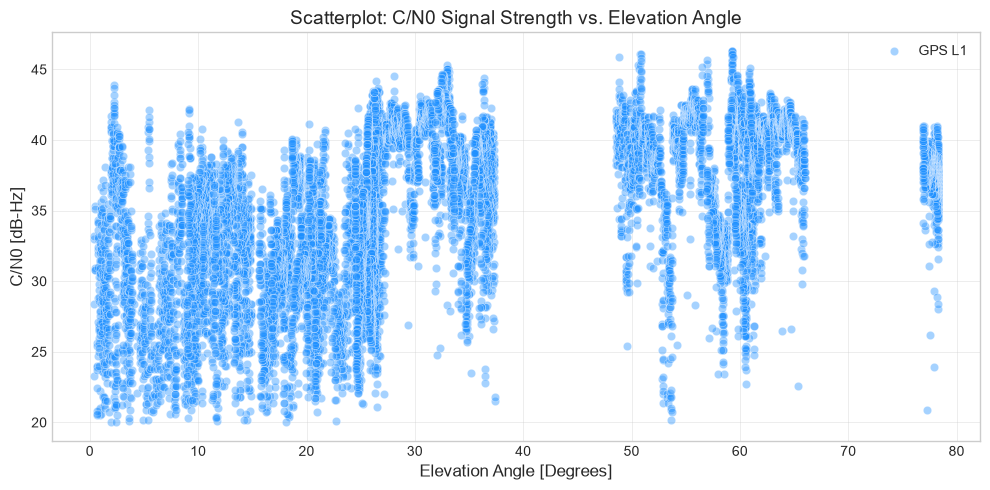

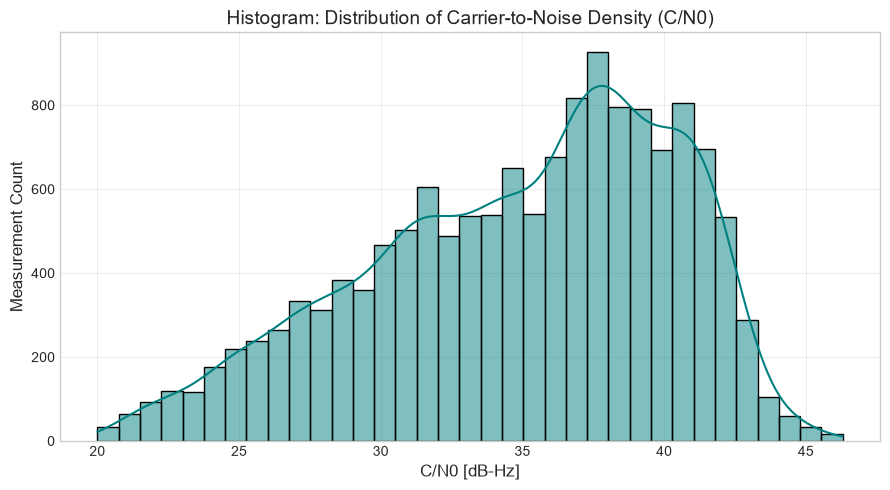

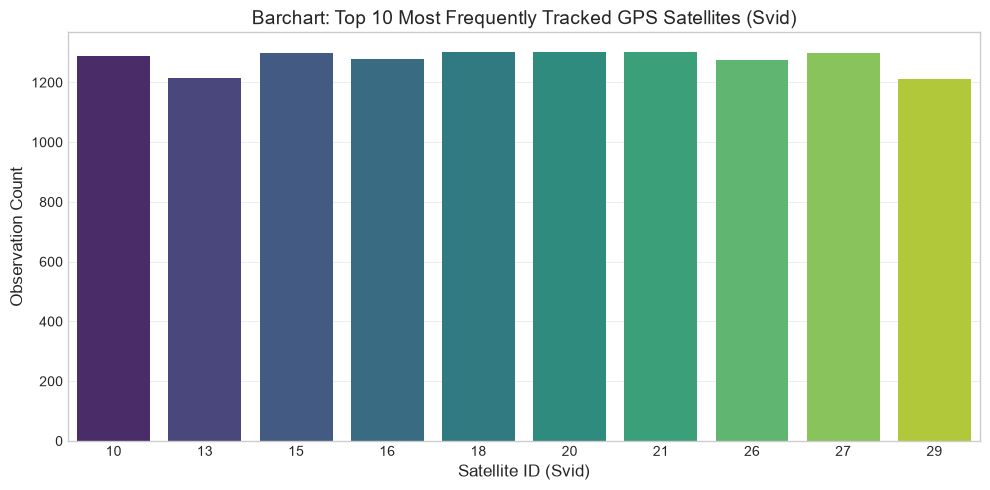

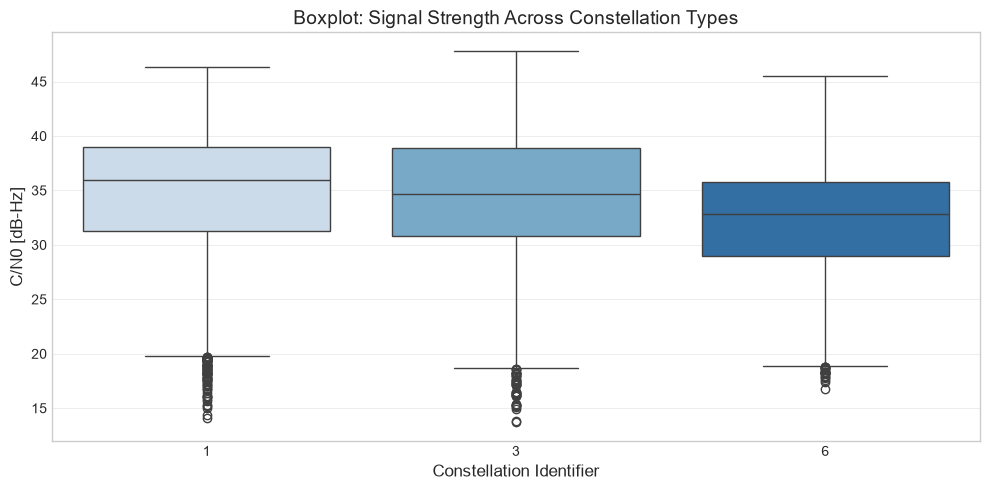

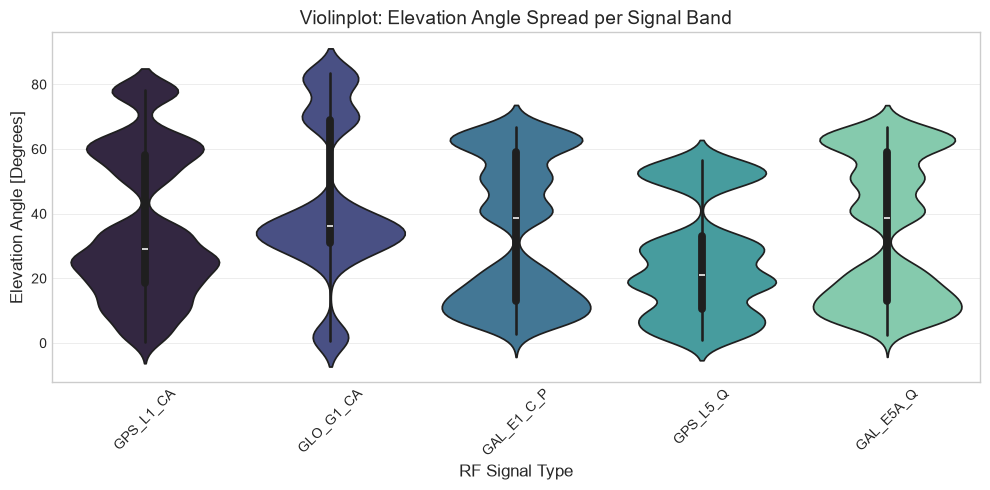

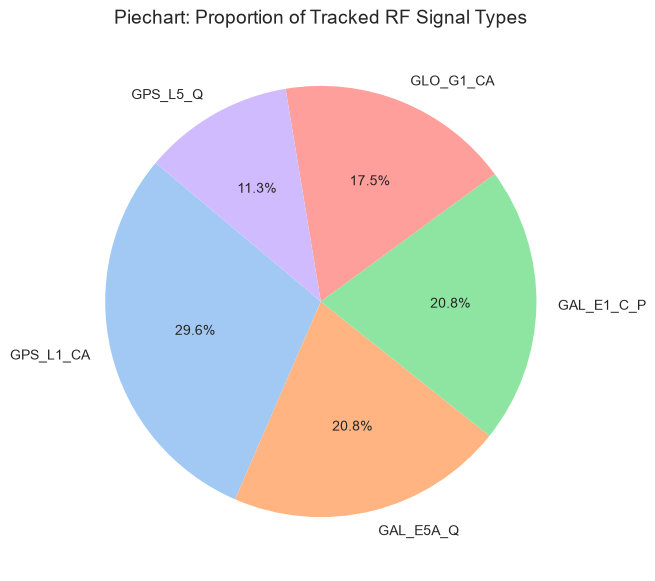

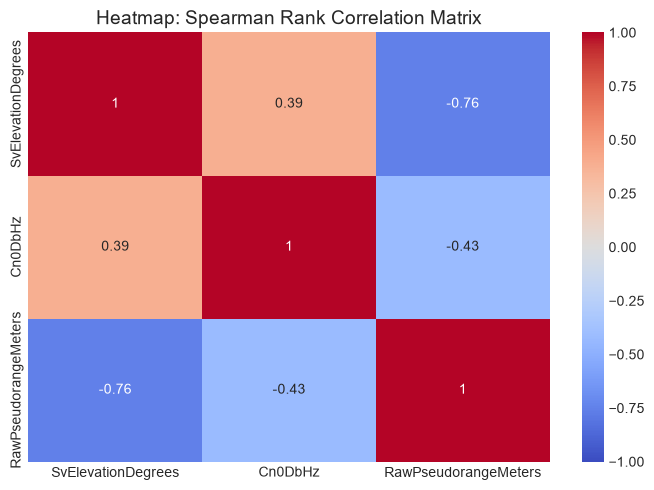

In [9]:
# Filter clean GPS L1 subset for visualization
clean_gps = df[(df["ConstellationType"] == 1) & (df["SignalType"] == "GPS_L1_CA")].copy()

# 1. Scatterplot: Elevation vs C/N0
plt.figure(figsize=(10, 5))
sns.scatterplot(data=clean_gps, x="SvElevationDegrees", y="Cn0DbHz", alpha=0.4, color="dodgerblue", label="GPS L1")
plt.title("Scatterplot: C/N0 Signal Strength vs. Elevation Angle", fontsize=14)
plt.xlabel("Elevation Angle [Degrees]", fontsize=12)
plt.ylabel("C/N0 [dB-Hz]", fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

# 2. Histogram: C/N0 Distribution
plt.figure(figsize=(9, 5))
sns.histplot(clean_gps["Cn0DbHz"], bins=35, kde=True, color="teal")
plt.title("Histogram: Distribution of Carrier-to-Noise Density (C/N0)", fontsize=14)
plt.xlabel("C/N0 [dB-Hz]", fontsize=12)
plt.ylabel("Measurement Count", fontsize=12)
plt.tight_layout()
plt.show()

# 3. Barchart: Top Svid Frequency
plt.figure(figsize=(10, 5))
top_svids = clean_gps["Svid"].value_counts().head(10)
sns.barplot(x=top_svids.index, y=top_svids.values, palette="viridis", legend=False)
plt.title("Barchart: Top 10 Most Frequently Tracked GPS Satellites (Svid)", fontsize=14)
plt.xlabel("Satellite ID (Svid)", fontsize=12)
plt.ylabel("Observation Count", fontsize=12)
plt.tight_layout()
plt.show()

# 4. Boxplot: C/N0 by Constellation Type
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="ConstellationType", y="Cn0DbHz", palette="Blues")
plt.title("Boxplot: Signal Strength Across Constellation Types", fontsize=14)
plt.xlabel("Constellation Identifier", fontsize=12)
plt.ylabel("C/N0 [dB-Hz]", fontsize=12)
plt.tight_layout()
plt.show()

# 5. Violinplot: Elevation Spread per Signal Band
plt.figure(figsize=(10, 5))
sns.violinplot(data=df, x="SignalType", y="SvElevationDegrees", palette="mako")
plt.title("Violinplot: Elevation Angle Spread per Signal Band", fontsize=14)
plt.xlabel("RF Signal Type", fontsize=12)
plt.ylabel("Elevation Angle [Degrees]", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 6. Piechart: Proportion of Signal Types
plt.figure(figsize=(7, 7))
signal_counts = df["SignalType"].value_counts()
plt.pie(signal_counts, labels=signal_counts.index, autopct="%1.1f%%", startangle=140, colors=sns.color_palette("pastel"))
plt.title("Piechart: Proportion of Tracked RF Signal Types", fontsize=14)
plt.show()

# 7. Heatmap: Spearman Correlation Matrix
plt.figure(figsize=(7, 5))
sns.heatmap(num_df.corr(method="spearman"), annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Heatmap: Spearman Rank Correlation Matrix", fontsize=14)
plt.tight_layout()
plt.show()



---
## 8. Index Structure Analysis
We verify whether the DataFrame index is unique, monotonically increasing, time-ordered by GPS epoch time, and examine time-varying properties.
    


In [10]:
print("=" * 70)
print("SECTION 8: INDEX STRUCTURE ANALYSIS")
print("=" * 70)
print(f"Is DataFrame Index Unique? -> {df.index.is_unique}")
print(f"Is DataFrame Index Monotonically Increasing? -> {df.index.is_monotonic_increasing}")

if "ReceivedSvTimeNanosSinceGpsEpoch" in df.columns:
    is_time_sorted = df["ReceivedSvTimeNanosSinceGpsEpoch"].is_monotonic_increasing
    print(f"Is Dataset Monotonically Sorted by GPS Time? -> {is_time_sorted}")
print("=" * 70)


SECTION 8: INDEX STRUCTURE ANALYSIS
Is DataFrame Index Unique? -> True
Is DataFrame Index Monotonically Increasing? -> True
Is Dataset Monotonically Sorted by GPS Time? -> False



---
## 9. Insights & Data Story
### 9.1 Core Analytical Insights
1. **Signal Strength vs. Elevation Coupling:** Higher elevation satellites consistently exhibit higher $C/N_0$ carrier-to-noise ratios due to minimal atmospheric and structural attenuation.
2. **Multipath Dominance:** A significant portion of low-elevation signals ($<30^\circ$) drop below reliable tracking thresholds, indicating urban multipath interference.
3. **Constellation Disparity:** Different GNSS constellations display distinct signal stability profiles, highlighting varying ephemeris accuracy and receiver sensitivity across frequencies.

### 9.2 Biases, Risks & Engineering Failure Points
* **Urban Canyon Bias:** The dataset is heavily biased toward metropolitan environments, meaning models trained solely on this data will fail in open-sky rural conditions.
* **Statistical Risk:** Non-normal telemetry error distributions can cause standard parametric filters (like standard Kalman filters) to diverge if robust outlier rejection is not applied.

### 9.3 Student Learnings & Perspective Shift
* **Data is Not Truth:** Raw GNSS measurements are physical sensor outputs subjected to severe thermal noise, clock bias, and multipath propagation rather than pristine ground-truth coordinates.
    



---
## 10. Bonus - Domain Feature Engineering (`Is_Reliable_LOS`)
We engineer a reliable Line-of-Sight (LOS) binary classifier based on satellite elevation ($\geq 40^\circ$) and signal strength ($\geq 37$ dB-Hz) to filter out multipath reflections.
    


In [11]:
enhanced_df = df.copy()
enhanced_df["Is_Reliable_LOS"] = np.where(
    (enhanced_df["SvElevationDegrees"] >= 40) & (enhanced_df["Cn0DbHz"] >= 37),
    1, 0
)

los_pct = enhanced_df["Is_Reliable_LOS"].mean() * 100
print("=" * 70)
print("SECTION 10: BONUS FEATURE ENGINEERING")
print("=" * 70)
print(f"Engineered Feature 'Is_Reliable_LOS' successfully created.")
print(f"Reliable Line-of-Sight (LOS) Ratio: {los_pct:.2f}% of observations.")
print("=" * 70)


SECTION 10: BONUS FEATURE ENGINEERING
Engineered Feature 'Is_Reliable_LOS' successfully created.
Reliable Line-of-Sight (LOS) Ratio: 16.71% of observations.
